# PCA and k-means

PCA and k-means are both unsupervised methods, but they describe different structures. PCA finds directions that preserve variance. k-means assigns observations to groups represented by centroids.


## Principal component analysis

PCA first centers the features and then finds the eigenvectors of the covariance matrix. The eigenvector with the largest eigenvalue is the direction of greatest remaining variance. The sign of an eigenvector is arbitrary, so a component and its negative represent the same direction.


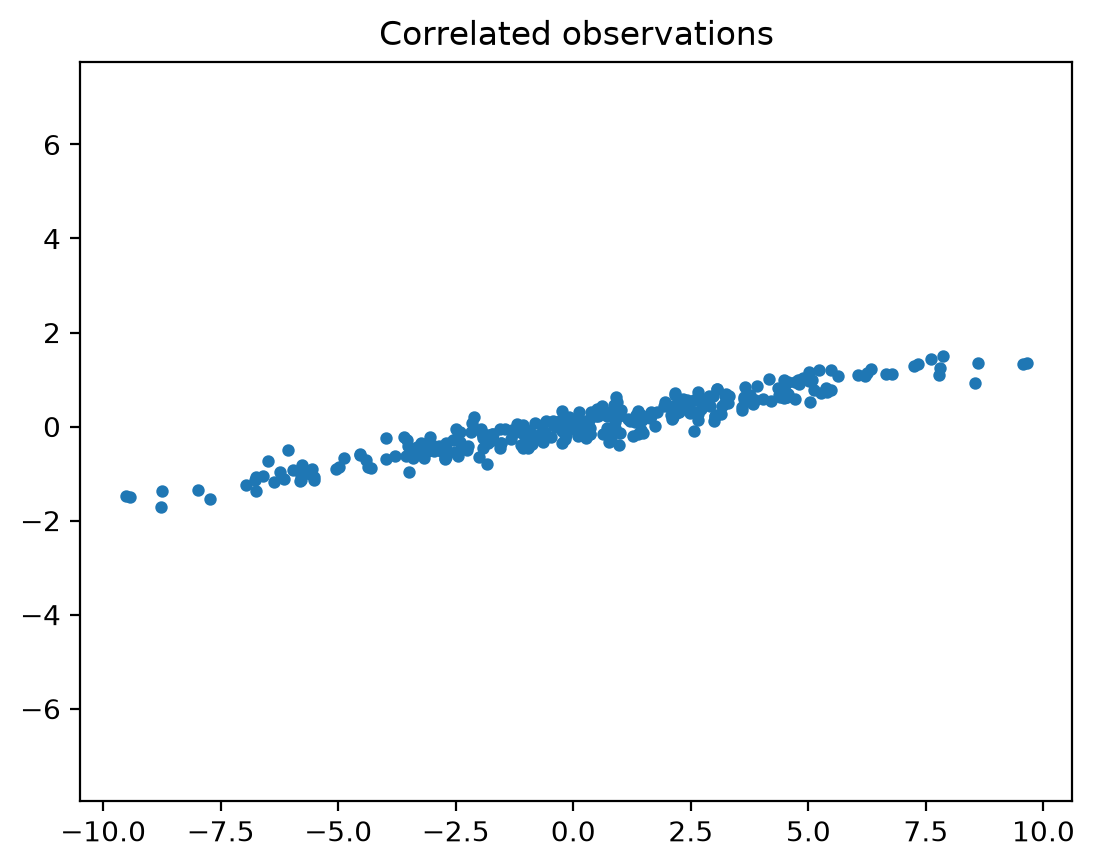

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(44)
base = rng.normal(size=(300, 2))
transform = np.array([[3.0, 2.0], [0.4, 0.5]])
X = base @ transform.T

plt.scatter(X[:, 0], X[:, 1], s=12)
plt.axis('equal')
plt.title('Correlated observations')
plt.show()

## Projection and explained variance

The projection is

```text
Z = (X - mean) @ components
```

The explained-variance ratio describes how much variation is retained by each component. High variance is not necessarily high predictive value; PCA does not use a target variable.


eigenvalues: [13.743  0.037]
variance split: [0.997 0.003]


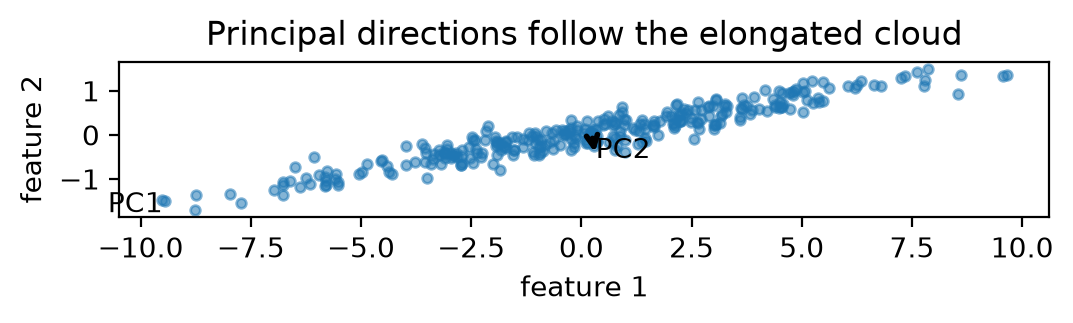

In [2]:
def fit_pca(X, components):
    mean = X.mean(axis=0)
    centered = X - mean
    covariance = centered.T @ centered / (len(X) - 1)
    values, vectors = np.linalg.eigh(covariance)
    order = np.argsort(values)[::-1]
    return mean, values[order][:components], vectors[:, order][:, :components]

def transform_pca(X, mean, vectors):
    return (X - mean) @ vectors

mean, values, vectors = fit_pca(X, components=2)
Z = transform_pca(X, mean, vectors)
explained = values / values.sum()
print('eigenvalues:', np.round(values, 3))
print('variance split:', np.round(explained, 3))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.55)
for value, vector, label in zip(values, vectors.T, ['PC1', 'PC2']):
    endpoint = mean + vector * np.sqrt(value) * 3
    ax.annotate('', xy=endpoint, xytext=mean, arrowprops={'arrowstyle': '->', 'lw': 2})
    ax.text(*endpoint, label)
ax.set(title='Principal directions follow the elongated cloud', xlabel='feature 1', ylabel='feature 2', aspect='equal')
plt.show()


## k-means

k-means alternates between assigning each point to its nearest centroid and replacing each centroid with the mean of its assigned points. It minimizes the sum of squared distances within clusters. The scale of the features and the initial centroids both affect the result.


inertia across seeds: [ 197.8  197.8 1403.4  197.8  197.8  197.8]


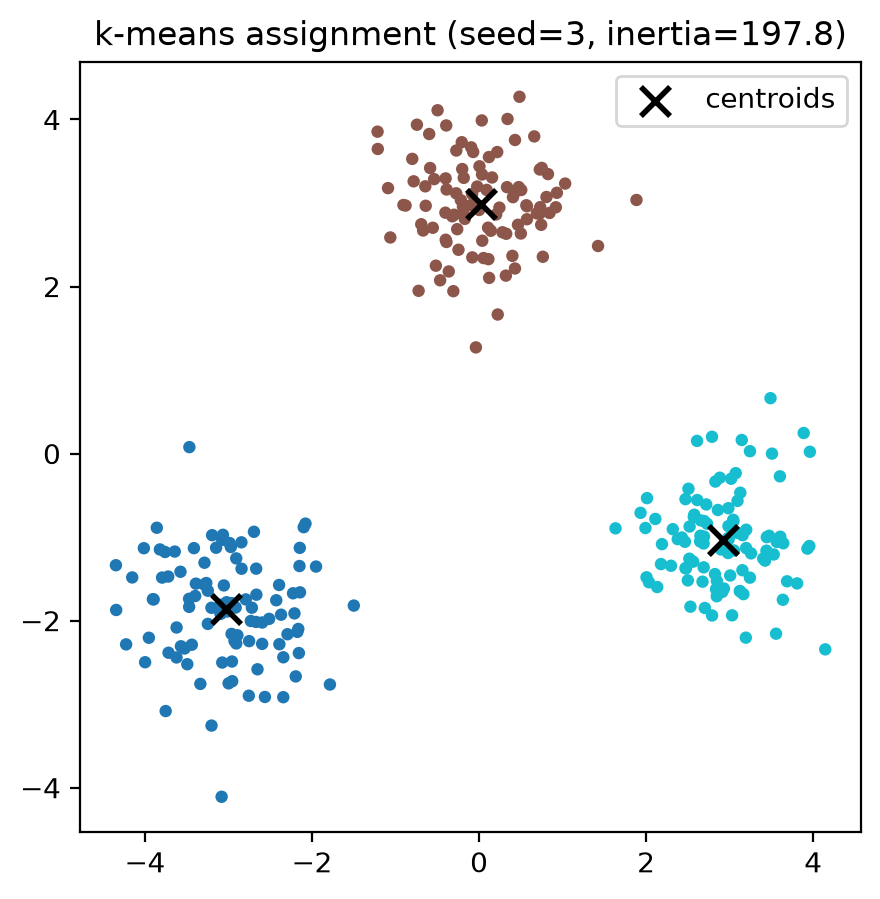

In [3]:
centers = np.array([[-3., -2.], [0., 3.], [3., -1.]])
clusters = np.vstack([rng.normal(center, 0.6, size=(100, 2)) for center in centers])

def fit_kmeans(X, k, seed=0, steps=50):
    local_rng = np.random.default_rng(seed)
    centroids = X[local_rng.choice(len(X), size=k, replace=False)].copy()
    for _ in range(steps):
        distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        labels = distances.argmin(axis=1)
        updated = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j] for j in range(k)])
        if np.allclose(updated, centroids):
            break
        centroids = updated
    distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels = distances.argmin(axis=1)
    inertia = distances[np.arange(len(X)), labels].sum()
    return labels, centroids, inertia

runs = [fit_kmeans(clusters, k=3, seed=seed) for seed in range(6)]
labels, learned, inertia = runs[3]
print('inertia across seeds:', np.round([run[2] for run in runs], 1))
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(clusters[:, 0], clusters[:, 1], c=labels, s=12, cmap='tab10')
ax.scatter(learned[:, 0], learned[:, 1], marker='x', s=110, color='black', linewidths=2, label='centroids')
ax.set(title=f'k-means assignment (seed=3, inertia={inertia:.1f})', aspect='equal')
ax.legend()
plt.show()


## Initialization and interpretation

The notebook repeats k-means with several random seeds and reports the inertia. Different runs can converge to different local optima. Cluster labels are identifiers assigned by the algorithm and do not have an inherent order or semantic meaning.
